This project focuses on finding an improving the following metrics

- Customer aquisition: How much it costs to aquire a customer
- Click through rate (CTR): How effective the markwting channels are
- Customer lifetime yesterday (CTR): Predicts the total value a customer will bring over their lifetime
- Churn rate: Percentage of customers who stop buying

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick  
%matplotlib inline


In [6]:
df = pd.read_csv('Dataset\marketing_data.csv')
df.head()

,Age,Income,PurchaseFrequency,Revenue,MarketingCost,CustomerID,Visitors,Purchases,Gender,Channel,Campaign,Impressions,Clicks,Churn
0,68,33909,14,971,3558,1,681,6,Male,Social Media,Fall Sale,4078,878,0
1,40,53138,2,9049,2995,2,401,8,Female,TV,Summer Sale,9272,916,0
2,58,32494,17,9180,2274,3,887,2,Male,Radio,Winter Sale,7517,377,0
3,37,79304,15,8935,4072,4,574,7,Female,Social Media,Winter Sale,2997,690,1
4,25,77574,18,6744,2749,5,400,7,Female,Social Media,Fall Sale,6687,680,1


In [8]:
print(df.describe())

               Age        Income  PurchaseFrequency      Revenue  \
count  1500.000000   1500.000000        1500.000000  1500.000000   
mean     43.387333  65266.621333          10.248000  5081.492000   
std      15.193305  19881.833490           5.462086  2862.472623   
min      18.000000  30124.000000           1.000000   108.000000   
25%      30.000000  47886.000000           5.000000  2568.750000   
50%      44.000000  65770.000000          10.000000  5052.000000   
75%      56.000000  82036.750000          15.000000  7626.250000   
max      69.000000  99959.000000          19.000000  9991.000000   

       MarketingCost   CustomerID    Visitors    Purchases  Impressions  \
count    1500.000000  1500.000000  1500.00000  1500.000000  1500.000000   
mean     2503.871333   750.500000   552.88600     5.065333  5455.698667   
std      1410.744312   433.157015   259.44433     2.575556  2588.759458   
min        54.000000     1.000000   100.00000     1.000000  1005.000000   
25%      129

In [37]:
#categorise into numeriacal and categorical data
num = df.select_dtypes(include= 'number')
cat = df.select_dtypes(exclude = 'number')

num.head()

,Age,Income,PurchaseFrequency,Revenue,MarketingCost,CustomerID,Visitors,Purchases,Impressions,Clicks,Churn,CTR,CAC,ConversionRate
0,68,33909,14,971,3558,1,681,6,4078,878,0,0.215302,5.224670,0.006834
1,40,53138,2,9049,2995,2,401,8,9272,916,0,0.098792,7.468828,0.008734
2,58,32494,17,9180,2274,3,887,2,7517,377,0,0.050153,2.563698,0.005305
3,37,79304,15,8935,4072,4,574,7,2997,690,1,0.230230,7.094077,0.010145
4,25,77574,18,6744,2749,5,400,7,6687,680,1,0.101690,6.872500,0.010294


Calculating additional metrics

In [11]:
#df['Total_Spent'] = df['Avg_Spent'] * df['Visits']
df['CTR'] = df['Clicks'] / df['Impressions']
df['CAC'] = df['MarketingCost'] / df['Visitors']
df['ConversionRate'] = df['Purchases'] / df['Clicks']
print(df[['CTR', 'CAC', 'ConversionRate']].describe())

               CTR          CAC  ConversionRate
count  1500.000000  1500.000000     1500.000000
mean      0.132779     6.305416        0.040056
std       0.136874     6.322493        0.234003
min       0.000178     0.068259        0.001013
25%       0.047742     2.346384        0.005398
50%       0.091840     4.444807        0.009770
75%       0.160853     7.800951        0.018519
max       0.974435    45.490741        5.000000


EDA

We want to make patterns in the data more understandable using visualizations
we will plot the distribution of age, income and revenue to determine customer segment


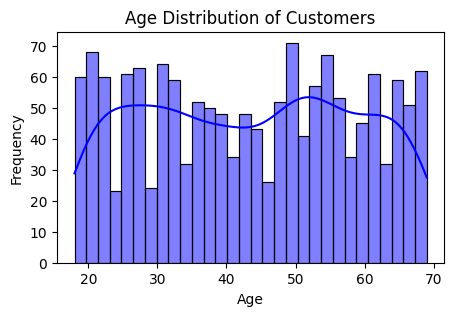

In [15]:
#Age distribution
plt.figure(figsize=(5, 3))
sns.histplot(df['Age'], bins=30, kde=True, color='blue')        
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

###### age 20-35 and 50 -70 have the highest frequency

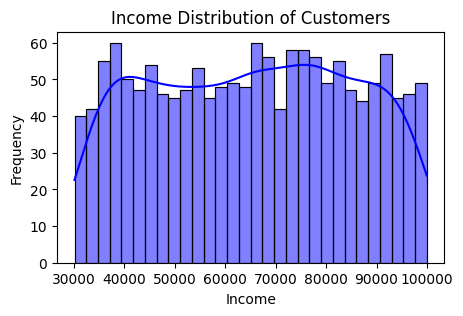

In [16]:
#Income distribution
plt.figure(figsize=(5, 3))
sns.histplot(df['Income'], bins=30, kde=True, color='blue')        
plt.title('Income Distribution of Customers')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

###### frequency is is evenly distributed across all income range 

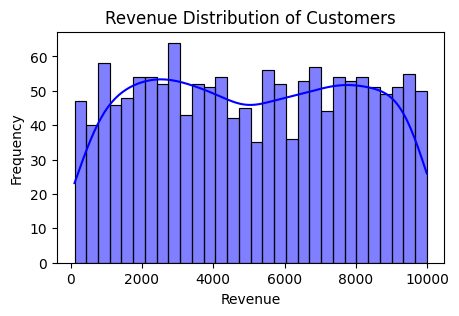

In [17]:
#Revenue distribution
plt.figure(figsize=(5, 3))
sns.histplot(df['Revenue'], bins=30, kde=True, color='blue')        
plt.title('Revenue Distribution of Customers')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

###### revenie is evenly distrubted across all customers

##### Analyze campaign effectiveness

Different channels may have different levels of success. we can use bar plots to compare the performance of each channel in terms of impression and clicks

C:\Users\USER\AppData\Local\Temp\ipykernel_15072\4171943430.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Channel', y='Impressions', data=df, estimator=np.sum, ci=None, palette='viridis')
C:\Users\USER\AppData\Local\Temp\ipykernel_15072\4171943430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Channel', y='Impressions', data=df, estimator=np.sum, ci=None, palette='viridis')


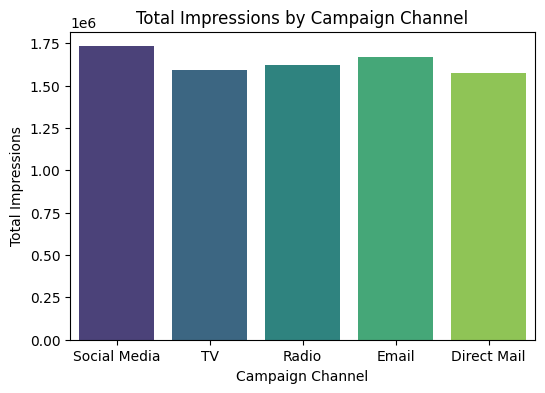

In [24]:
#barplot for cmapaign channels based on impressions
plt.figure(figsize=(6, 4))
sns.barplot(x='Channel', y='Impressions', data=df, estimator=np.sum, ci=None, palette='viridis')
plt.title('Total Impressions by Campaign Channel')
plt.xlabel('Campaign Channel')
plt.ylabel('Total Impressions')
plt.show()

###### social media has the highest impressions followed by emails

C:\Users\USER\AppData\Local\Temp\ipykernel_15072\4140218498.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Channel', y='Clicks', data=df, estimator=np.sum, ci=None, palette='viridis')
C:\Users\USER\AppData\Local\Temp\ipykernel_15072\4140218498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Channel', y='Clicks', data=df, estimator=np.sum, ci=None, palette='viridis')


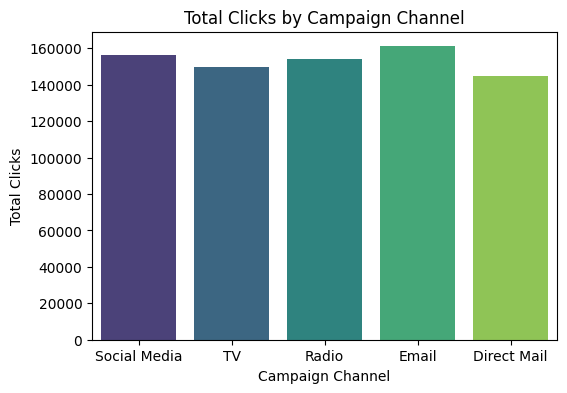

In [22]:
#barplot for cmapaign channels based on clicks
plt.figure(figsize=(6, 4))
sns.barplot(x='Channel', y='Clicks', data=df, estimator=np.sum, ci=None, palette='viridis')
plt.title('Total Clicks by Campaign Channel')
plt.xlabel('Campaign Channel')
plt.ylabel('Total Clicks')
plt.show()

###### email has the highest clicks followed by social media

##### Analyze campaign effectiveness

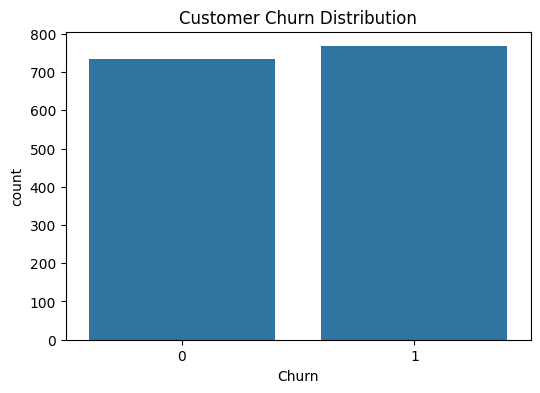

In [31]:
# Barplot for churned vs non-churned customers
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_15072\2559517831.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Channel', y='Churn', data=df, estimator=np.mean, errorbar=None, palette='viridis')


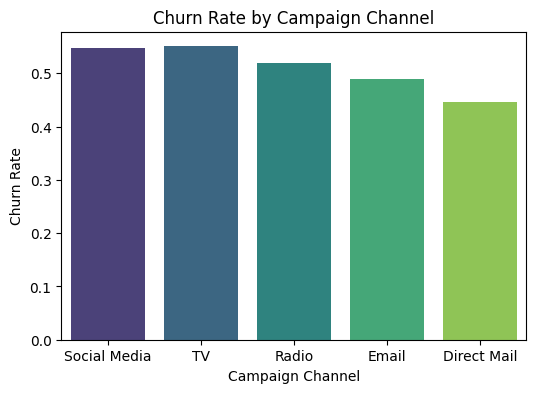

In [32]:
# Barplot for churn rate by campaign channel
plt.figure(figsize=(6, 4))
sns.barplot(x='Channel', y='Churn', data=df, estimator=np.mean, errorbar=None, palette='viridis')
plt.title('Churn Rate by Campaign Channel')
plt.xlabel('Campaign Channel')
plt.ylabel('Churn Rate')
plt.show()

###### TV, Social media and Radio have the highest churn while Direct mail has the lowest

##### Relationships between variables 

1. Correlation Matrix: we want to see the correlation between numerical variables to identify strong relationships

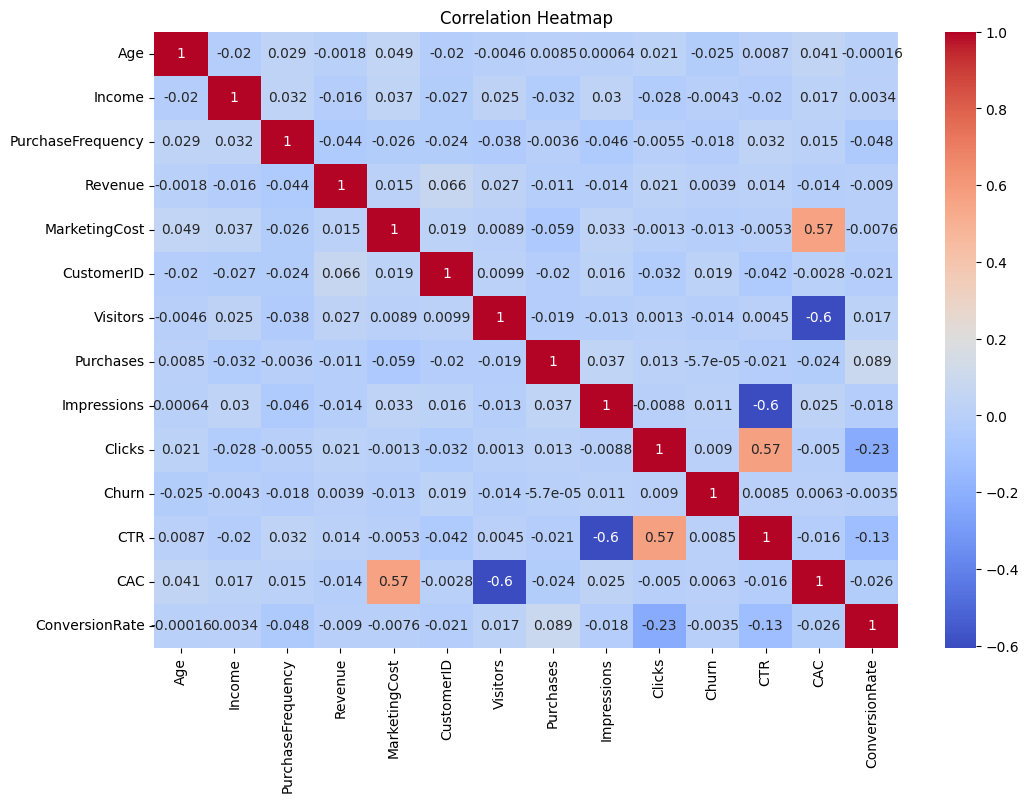

In [40]:
#correlation heatmap
plt.figure(figsize=(12, 8))
corr = num.corr()    
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

2. Scatter plot to explore revenue vs marketing cost

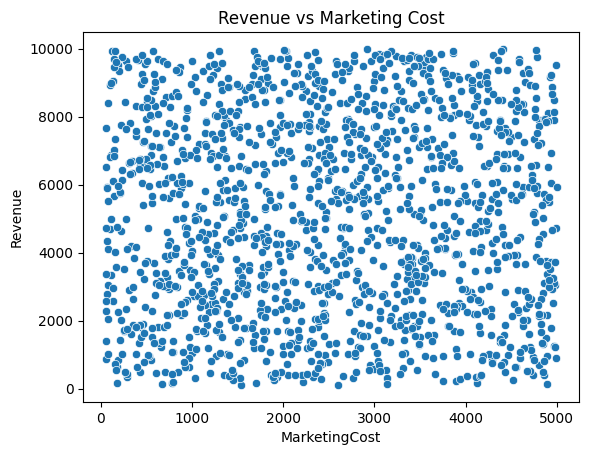

In [44]:
#Scatter plot to explore revenue vs marketing cost
sns.scatterplot(x = 'MarketingCost', y ='Revenue', data=df)
plt.title('Revenue vs Marketing Cost')
plt.show()